In [1]:
import lfox
import lfox.lattice as lat
import lfox.evolution.hmc as lhmc
import jax
import jax.numpy as jnp
import numpy as np

# Imports below require "dev" environment
import matplotlib.pyplot as plt
import lsqfit
import gvar as gv
import tqdm

# Double precision!
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_threefry_partitionable", True)

# Disable metal due to issues...
#jax.config.update('jax_platform_name', 'cpu')


In [2]:
class ScalarAction(lhmc.Action):        

    @staticmethod
    @jax.jit
    def _S(fields, params):
        phi = fields[0]
        S = phi**2
        
        for ax in range(phi.d()):
            S -= 2 * params['kappa'] * phi * phi.nn_field(ax)

        S += params['lambda'] * (phi**2 - 1)**2
        return S
    
    # Exact force function instead of autodiff, for testing purposes
    @staticmethod
    @jax.jit
    def exact_force(fields, params):
        phi = fields[0]

        J = phi.nn_field(axis=0, shift=1) + phi.nn_field(axis=0, shift=-1)
        for ax in range(1,phi.d):
            J += phi.nn_field(axis=ax, shift=1)
            J += phi.nn_field(axis=ax, shift=-1)

        F = -2 * params['kappa'] * J
        F += 2 * phi.F
        F += 4 * params['lambda'] * (phi.F**2 - 1) * phi.F

        return F

In [4]:
%%time

# First test case: exercise 2.5
d = 4
Lat4 = lat.SquareLattice(st_dims=((4,)*d))
phi4 = lat.LatticeField(lattice=Lat4, F=1)

S4 = ScalarAction(field_names=['phi'], params={'kappa': 0.18169, 'lambda': 1.3282})

all_Nstep = np.array([10, 20, 30, 40, 50])
all_eps = 1/all_Nstep

all_dH_leap = []
all_dH_om = []

rng_key = jax.random.PRNGKey(48119)

for eps, Nstep in zip(all_eps, all_Nstep):
    HMC_leap = lhmc.HMCRewrite(
        action=S4,
        integrator=lhmc.LeapfrogIntegrator(eps=eps, Nstep=Nstep),
    )
    HMC_om = lhmc.HMCRewrite(
        action=S4,
        integrator=lhmc.OmelyanIntegrator(eps=eps, Nstep=Nstep),
    )

    F4 = {'phi': phi4}
    F4, monitor_leap, rng_key = HMC_leap.evolve_many(F4, rng_key, traj=50, warmup=True)

    F4 = {'phi': phi4}
    F4, monitor_om, rng_key = HMC_om.evolve_many(F4, rng_key, traj=50, warmup=True)

    abs_dH_leap = np.abs(np.array(monitor_leap['delta_H']))
    abs_dH_om = np.abs(np.array(monitor_om['delta_H']))

    all_dH_leap.append(gv.dataset.avg_data(abs_dH_leap))
    all_dH_om.append(gv.dataset.avg_data(abs_dH_om))

CPU times: user 65 ms, sys: 6.7 ms, total: 71.7 ms
Wall time: 48.5 ms


<timed exec>:4: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.


Least Squares Fit:
  chi2/dof [dof] = 0.7 [5]    Q = 0.62    logGBF = 2.2574

Parameters:
              a   -0.0038 (24)      [ 0 ± 1.0e+02 ]  
              b     45.0 (3.7)      [ 0 ± 5.0e+02 ]  

Settings:
  svdcut/n = 1e-12/0    tol = (1e-08,1e-10*,1e-10)    (itns/time = 2/0.0s)
  fitter = scipy_least_squares    method = trf

Least Squares Fit:
  chi2/dof [dof] = 0.95 [5]    Q = 0.44    logGBF = 8.7762

Parameters:
              a   -0.00067 (25)      [ 0 ± 1.0e+02 ]  
              b       5.22 (36)      [ 0 ± 5.0e+02 ]  

Settings:
  svdcut/n = 1e-12/0    tol = (1e-08,1e-10*,1e-10)    (itns/time = 3/0.0s)
  fitter = scipy_least_squares    method = trf



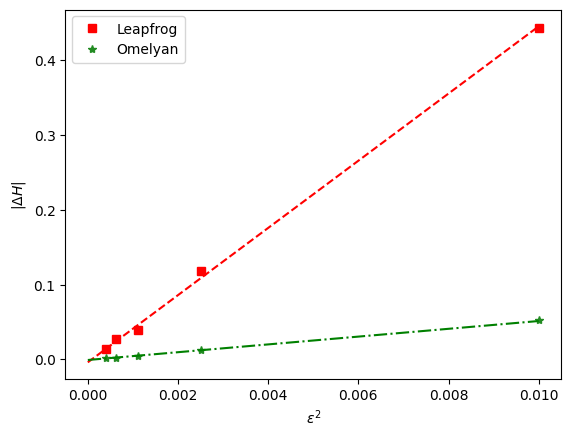

In [6]:
#Figure 2.2
plt.plot(all_eps**2, gv.mean(all_dH_leap), ls=' ', marker='s', color='red', label='Leapfrog')
plt.plot(all_eps**2
         , gv.mean(all_dH_om), ls=' ', marker='*', color='forestgreen', label='Omelyan')

def lin(x,p):
    return p['a'] + p['b']*x

fit_leap = lsqfit.nonlinear_fit(data=(all_eps**2, all_dH_leap), prior={'a': gv.gvar(0,100), 'b': gv.gvar(0,500)}, fcn=lin)
print(fit_leap)

eps_ls = np.linspace(0,0.1,100)
plt.plot(eps_ls**2, gv.mean(lin(eps_ls**2,fit_leap.p)), ls='--', color='red')

fit_om = lsqfit.nonlinear_fit(data=(all_eps**2, all_dH_om), prior={'a': gv.gvar(0,100), 'b': gv.gvar(0,500)}, fcn=lin)
print(fit_om)

plt.plot(eps_ls**2, gv.mean(lin(eps_ls**2,fit_om.p)), ls='-.', color='green')

plt.xlabel('$\\epsilon^2$')
plt.ylabel('$|\\Delta H|$')
plt.legend()

Another technical plot first: let's do figure 2.4.

In [7]:
%%time

# First test case: exercise 2.5
d = 3
Lat6 = lat.SquareLattice(st_dims=((6,)*d))
phi6 = lat.LatticeField(lattice=Lat6, F=1)

S6 = ScalarAction(field_names=['phi'], params={'kappa': 0.185825, 'lambda': 1.1689})

all_Nstep = np.array([4, 5, 7, 8, 10, 20, 30, 40, 50])
all_eps = 1/all_Nstep

all_acc_rate = []
rng_key = jax.random.PRNGKey(11134)

for eps, Nstep in zip(all_eps, all_Nstep):
    F6 = {'phi': phi6}
    HMC = lhmc.HMCRewrite(
        action=S6,
        integrator=lhmc.LeapfrogIntegrator(eps=eps, Nstep=Nstep),
    )

#    acc_rate = []
    F6, mon, rng_key = HMC.evolve_many(F6, rng_key, traj=1000, warmup=False)
    all_acc_rate.append(np.mean(mon['accept']))
#    for _ in range(1000):
#        F6, mon, rng_key = HMC.evolve(F6, rng_key, warmup=False)
#        acc_rate.append(mon['accept'])

#    all_acc_rate.append(np.mean(np.array(acc_rate)))
    

<timed exec>:4: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
/opt/homebrew/Cellar/python@3.13/3.13.3/Frameworks/Python.framework/Versions/3.13/lib/python3.13/dataclasses.py:1630: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return self.__class__(**changes)


CPU times: user 888 ms, sys: 109 ms, total: 997 ms
Wall time: 565 ms


<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
/var/folders/vb/_ph7q5kx1db93rd8bw2112ph0000gn/T/ipykernel_95261/1767568451.py:3: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon^2$')


Text(0, 0.5, 'acc rate')

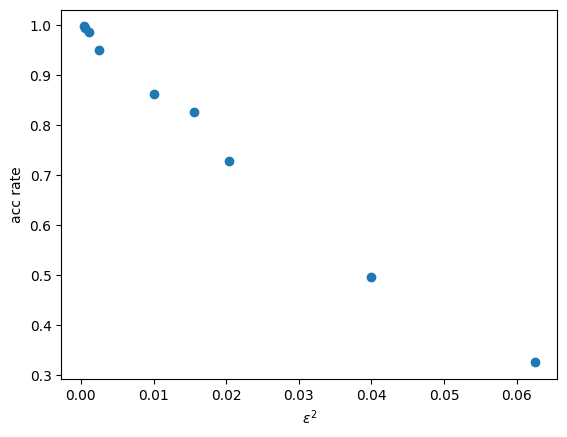

In [8]:
plt.plot(all_eps**2, all_acc_rate, ls=' ', marker='o')

plt.xlabel('$\epsilon^2$')
plt.ylabel('acc rate')

Text(0, 0.5, '$1/\\epsilon/$ acc rate [cost]')

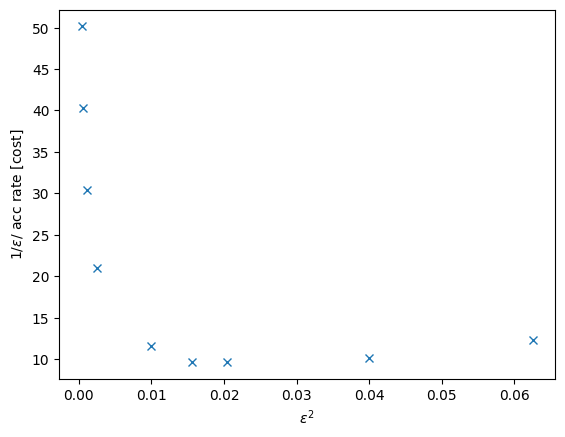

In [9]:
plt.plot(all_eps**2, 1/all_eps/all_acc_rate, ls=' ', marker='x')
plt.xlabel('$\\epsilon^2$')
plt.ylabel('$1/\\epsilon/$ acc rate [cost]')

Some additional technical tests.  Let's verify that $e^{-\Delta H}$ averages to 1 properly.

In [12]:
%%time
HMC = lhmc.HMCRewrite(
    action=ScalarAction(field_names=['phi'], params={'kappa': 0.18, 'lambda': 1.145}),
    integrator=lhmc.LeapfrogIntegrator(eps=0.1, Nstep=10),
)

Ftest = {'phi': phi6}
rng_key = jax.random.PRNGKey(21245)
dH_array = []
for _ in range(10000):
    Ftest, mon, rng_key = HMC.evolve(Ftest, rng_key, warmup=False)
    dH_array.append(mon['delta_H'])

CPU times: user 1 s, sys: 214 ms, total: 1.21 s
Wall time: 548 ms


0.999(20)

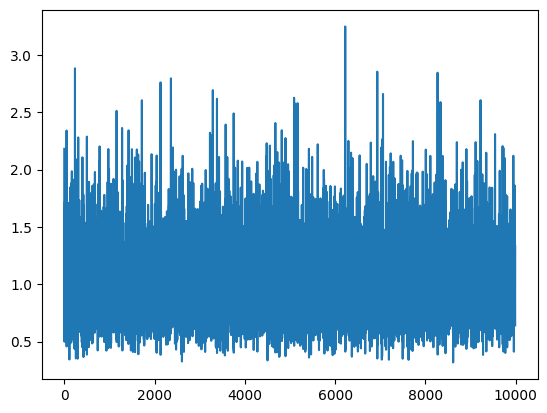

In [13]:
edH = np.exp(-np.array(dH_array))
plt.plot(edH[10:])
gv.dataset.avg_data(edH[100::50])  # Block by 50, should be consistent with 1

Now on to figure 2.3 and comparing HMC to MD.

In [14]:
@jax.jit
def mag(phi):
    m = jnp.sum(phi.F)
    return jnp.array([m, m**2, m**4])

def mag_obs(fields, params):
    return mag(fields['phi'])

In [15]:
%%prun -s cumulative

# Second test case: figure 2.3
d = 3
Lat6 = lat.SquareLattice(st_dims=((6,)*d))
phi6 = lat.LatticeField(lattice=Lat6, F=1)

all_Nstep = np.array([4,5,6,7,8,10])
all_eps = 1/all_Nstep
m2_HMC = []
m2_HMD = []

raw_HMC = []
mon_HMC = []

rng_key = jax.random.PRNGKey(73645)
F6_HMC = {'phi': phi6}
F6_HMD = {'phi': phi6}

for eps, Nstep in zip(all_eps, all_Nstep):
    print(eps, Nstep)

    raw_m2_HMC = []
    raw_m2_HMD = []

    # Only need one HMC object, HMD is the same thing but with warmups off
    HMC = lhmc.HMCRewrite(
        action=ScalarAction(field_names=['phi'], params={'kappa': 0.185825, 'lambda': 1.1689}),
        integrator=lhmc.LeapfrogIntegrator(eps=eps, Nstep=Nstep),
    )
        
    for t in range(1000):
        F6_HMC, _, rng_key = HMC.evolve_many(F6_HMC, rng_key, traj=100, warmup=False)
        F6_HMD, _, rng_key = HMC.evolve_many(F6_HMD, rng_key, traj=100, warmup=True)

        raw_m2_HMC.append(mag(F6_HMC['phi'])[1]/6**d)
        raw_m2_HMD.append(mag(F6_HMD['phi'])[1]/6**d)
    
    m2_HMC.append(gv.dataset.avg_data(raw_m2_HMC))
    m2_HMD.append(gv.dataset.avg_data(raw_m2_HMD))



<string>:4: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.


0.25 4
0.2 5
0.16666666666666666 6
0.14285714285714285 7
0.125 8
0.1 10
 

         3500225 function calls (3495737 primitive calls) in 29.659 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     49/4    0.000    0.000   29.661    7.415 base_events.py:1954(_run_once)
       29    9.078    0.313   18.982    0.655 {built-in method time.sleep}
    12000    0.029    0.000   14.575    0.001 array.py:345(__getitem__)
    12000    0.008    0.000   14.520    0.001 indexing.py:619(rewriting_take)
    12000    0.157    0.000   14.512    0.001 indexing.py:524(_attempt_rewriting_take_via_slice)
24223/24221    0.019    0.000   14.141    0.001 core.py:529(bind)
24223/24221    0.041    0.000   14.049    0.001 core.py:533(_true_bind)
24223/24221    0.007    0.000   13.983    0.001 core.py:555(bind_with_trace)
    24011    0.025    0.000   13.951    0.001 core.py:1051(process_primitive)
    12008    0.009    0.000   13.905    0.001 slicing.py:57(slice)
    24009   13.775    0.001   13.848    0.001 dispatch.py:81

         3455826 function calls (3451618 primitive calls) in 33.706 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    12000    0.025    0.000   15.812    0.001 array.py:346(__getitem__)
    12000    0.007    0.000   15.765    0.001 indexing.py:616(rewriting_take)
    12000    0.139    0.000   15.757    0.001 indexing.py:525(_attempt_rewriting_take_via_slice)
24223/24221    0.019    0.000   15.432    0.001 core.py:494(bind)
24223/24221    0.025    0.000   15.345    0.001 core.py:498(_true_bind)
24223/24221    0.007    0.000   15.299    0.001 core.py:516(bind_with_trace)
    24011    0.022    0.000   15.273    0.001 core.py:1008(process_primitive)
    12008    0.008    0.000   15.224    0.001 slicing.py:57(slice)
    24009   15.106    0.001   15.189    0.001 dispatch.py:82(apply_primitive)
    12000    0.030    0.000   15.115    0.001 slicing.py:1427(_slice_impl)
        1    0.000    0.000    6.954    6.954 {built-in met

<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
/var/folders/vz/k6mgc8_d28v0gskwh5xd08mr0000gn/T/ipykernel_28206/1386904723.py:5: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon^2$')


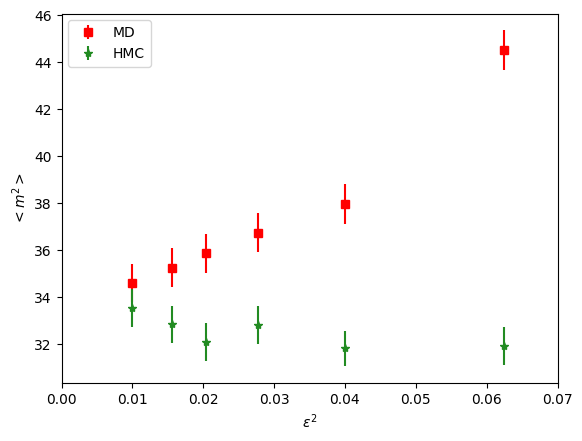

In [20]:
plt.errorbar(all_eps**2, gv.mean(m2_HMD), gv.sdev(m2_HMD), ls=' ', marker='s', color='red', label='MD')
plt.errorbar(all_eps**2, gv.mean(m2_HMC), gv.sdev(m2_HMC), ls=' ', marker='*', color='forestgreen', label='HMC')

plt.xlim(0,0.07)
plt.xlabel('$\epsilon^2$')
plt.ylabel('$<m^2>$')
plt.legend()

Finally the big physics result, figure 2.5!

In [21]:
from tqdm import tqdm

d = 3

all_kappa = np.array([0.05, 0.10, 0.15, 0.16, 0.17, 0.175, 0.18, 0.185, 0.19, 0.195, 0.2, 0.21, 0.22])
all_L = (6,8,10)

mag_k = {}
rng_key = jax.random.PRNGKey(58105)

for L in tqdm(all_L):
    mag_k[L] = []

    Lat = lat.SquareLattice(st_dims=((L,)*d))
    phi_L = lat.LatticeField(lattice=Lat, F=1)

    for k in all_kappa:
        raw_mag = []
        fields = {'phi': phi_L}
        Sk = ScalarAction(field_names=['phi'], params={'kappa': k, 'lambda': 1.1689})
    
        HMC = lhmc.HMCRewrite(
            action=Sk,
            integrator=lhmc.OmelyanIntegrator(eps=0.1, Nstep=10),
        )

        fields, _, rng_key = HMC.evolve_many(fields, rng_key, traj=100, warmup=True)
    
        for _ in range(200):
            fields, _, rng_key = HMC.evolve_many(fields, rng_key, traj=100)
            raw_mag.append(mag(fields['phi'])[0])
    
        raw_m = np.abs(np.array(raw_mag))/L**d
    
        mag_k[L].append(gv.dataset.avg_data(raw_m))
    

  0%|          | 0/3 [00:00<?, ?it/s]/var/folders/vz/k6mgc8_d28v0gskwh5xd08mr0000gn/T/ipykernel_28206/2342133672.py:15: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  phi_L = lat.LatticeField(lattice=Lat, F=1)
/var/folders/vz/k6mgc8_d28v0gskwh5xd08mr0000gn/T/ipykernel_28206/2342133672.py:20: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  Sk = ScalarAction(field_names=['phi'], params={'kappa': k, 'lambda': 1.1689})
100%|██████████| 3/3 [01:55<00:00, 38.52s/it]


(0.15, 0.22)

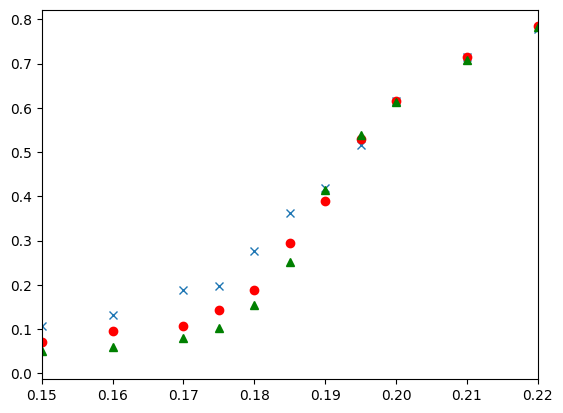

In [22]:
plt.plot(all_kappa, gv.mean(mag_k[6]), ls=' ', marker='x')
plt.plot(all_kappa, gv.mean(mag_k[8]), ls=' ', marker='o', color='red')
plt.plot(all_kappa, gv.mean(mag_k[10]), ls=' ', marker='^', color='green')

plt.xlim(0.15, 0.22)

Autocorrelation analysis...

In [64]:
d = 3
Lat6 = lat.SquareLattice(st_dims=((6,)*d))
phi6 = lat.LatticeField(lattice=Lat6, F=1)

# HMC = lhmc.HMCEvolver(
#     action=ScalarAction(field_names=['phi'], params={'kappa': 0.185825, 'lambda': 1.1689}),
#     seed=21245,
#     init_fields={'phi': phi6},
#     integrator=lhmc.OmelyanIntegrator(eps=0.1, Nstep=10),
#     observables={'mag': (mag_obs, 1)},
# )

HMC = lhmc.HMCRewrite(
    action=ScalarAction(field_names=['phi'], params={'kappa': 0.185825, 'lambda': 1.1689}),
    integrator=lhmc.LeapfrogIntegrator(eps=0.1, Nstep=10),
)

F6 = {'phi': phi6}
rng_key = jax.random.PRNGKey(29759)
F6, _, rng_key = HMC.evolve_many(F6, rng_key, traj=1000, warmup=True)

m2 = []
dH = []

for _ in tqdm(range(100000)):
    F6, mon, rng_key = HMC.evolve_many(F6, rng_key, traj=1)
    dH.append(np.mean(mon['delta_H']))
    m2.append(mag(F6['phi'])[1]/6**d)


/var/folders/vz/k6mgc8_d28v0gskwh5xd08mr0000gn/T/ipykernel_28206/3376543419.py:3: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  phi6 = lat.LatticeField(lattice=Lat6, F=1)
100%|██████████| 100000/100000 [00:10<00:00, 9123.69it/s]


In [65]:
gv.dataset.avg_data(np.exp(-np.asarray(dH)))

1.0013(11)

[Array(74.16398422, dtype=float64),
 Array(75.40130109, dtype=float64),
 Array(68.98404388, dtype=float64),
 Array(105.46343707, dtype=float64),
 Array(114.90217795, dtype=float64),
 Array(73.59443252, dtype=float64),
 Array(82.0620639, dtype=float64),
 Array(79.50955904, dtype=float64),
 Array(61.68039345, dtype=float64),
 Array(42.95876094, dtype=float64),
 Array(59.35241336, dtype=float64),
 Array(61.81873722, dtype=float64),
 Array(51.17476337, dtype=float64),
 Array(44.11023946, dtype=float64),
 Array(46.41991128, dtype=float64),
 Array(65.08941289, dtype=float64),
 Array(62.27098558, dtype=float64),
 Array(51.80734039, dtype=float64),
 Array(55.54882695, dtype=float64),
 Array(50.54289382, dtype=float64),
 Array(36.36743111, dtype=float64),
 Array(36.36743111, dtype=float64),
 Array(46.29574302, dtype=float64),
 Array(22.97397185, dtype=float64),
 Array(38.03902064, dtype=float64),
 Array(60.57896424, dtype=float64),
 Array(68.2791064, dtype=float64),
 Array(49.27066488, dtype=fl

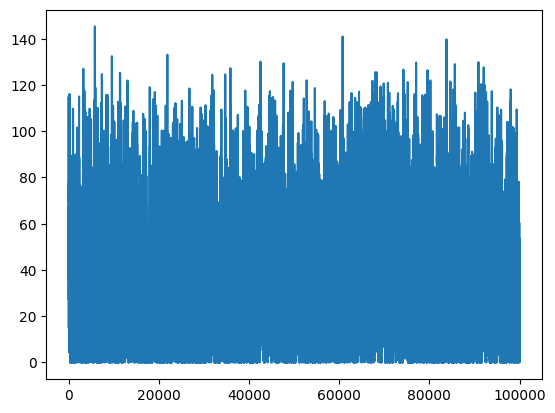

In [66]:
#m = np.array(HMC.obs_chain['mag'])[:,0]
plt.plot(m2)
m2

#gv.dataset.avg_data(m[::100]/6**3)

In [78]:
mu, Ns = np.mean(m2), len(m2)
print(mu, Ns)
print(len(m2))

def Gamma(t):
    C1 = m2 - mu
    C2 = np.roll(m2, t) - mu
    return gv.dataset.avg_data(C1[:Ns-t] * C2[:Ns-t] / (Ns - t))

%timeit Gamma(800)

33.0806971937291 100000
100000
605 ms ± 3.31 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [73]:
600*800/1000/60

8.0

<ErrorbarContainer object of 3 artists>

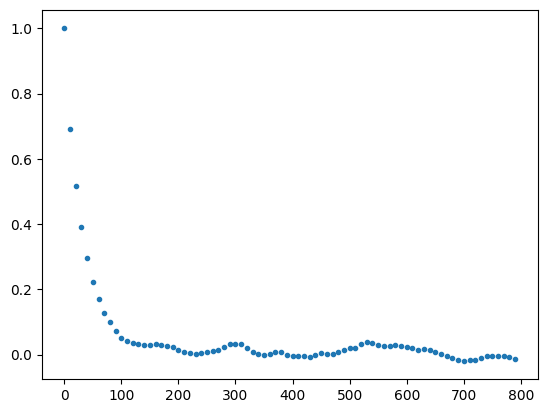

In [80]:

gam = [ Gamma(t)/Gamma(0) for t in range(0,800,10) ]
plt.errorbar(range(0,800,10), gv.mean(gam), gv.sdev(gam), ls=' ', marker='.')

<ErrorbarContainer object of 3 artists>

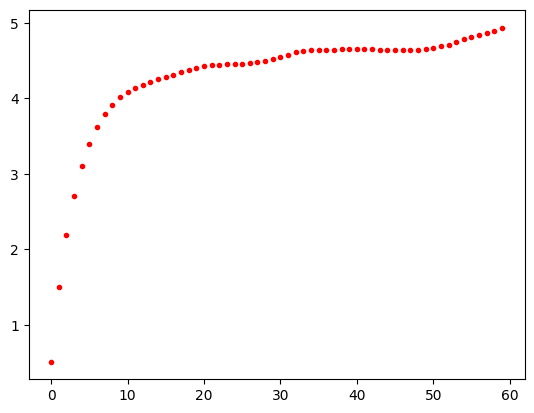

In [81]:
def tau(W):
    return 0.5 + np.sum(gam[:W])

taus = [ tau(W) for W in range(0,60) ]
plt.errorbar(range(0,60), gv.mean(taus), gv.sdev(taus), ls=' ', marker='.', color='red')